# Imports and Data Load

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, roc_auc_score, f1_score
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import SMOTE

import pickle
import requests
import json

import warnings
warnings.filterwarnings("ignore")
sns.set_theme()

In [2]:
df = pd.read_csv('bank-additional.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4119 entries, 0 to 4118
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             4119 non-null   int64  
 1   job             4119 non-null   object 
 2   marital         4119 non-null   object 
 3   education       4119 non-null   object 
 4   default         4119 non-null   object 
 5   housing         4119 non-null   object 
 6   loan            4119 non-null   object 
 7   contact         4119 non-null   object 
 8   month           4119 non-null   object 
 9   day_of_week     4119 non-null   object 
 10  duration        4119 non-null   int64  
 11  campaign        4119 non-null   int64  
 12  pdays           4119 non-null   int64  
 13  previous        4119 non-null   int64  
 14  poutcome        4119 non-null   object 
 15  emp.var.rate    4119 non-null   float64
 16  cons.price.idx  4119 non-null   float64
 17  cons.conf.idx   4119 non-null   f

# Exploratory Data Analysis (EDA)

## Null Value Check
Checking for null values in the data

In [3]:
df.isna().sum()

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

## Basic Statistical Summary (Univariate)

In [4]:
# identifynig the numerical and categorical columns

num_cols = list(df.describe().columns)
cat_cols = list(set(df.columns) - set(num_cols))

In [5]:
# Basic statistical summary for the numerical columns

df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000
mean,40.113620,256.788055,2.537266,960.422190,0.190337,0.084972,93.579704,-40.499102,3.621356,5166.481695
std,10.313362,254.703736,2.568159,191.922786,0.541788,1.563114,0.579349,4.594578,1.733591,73.667904
min,18.000000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.635000,4963.600000
25%,32.000000,103.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.334000,5099.100000
50%,38.000000,181.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.000000,317.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,88.000000,3643.000000,35.000000,999.000000,6.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


In [6]:
# Basic statistical summary for the categorical columns

df[cat_cols].describe(include = "all")

,job,marital,default,month,day_of_week,housing,loan,contact,education,y,poutcome
count,4119,4119,4119,4119,4119,4119,4119,4119,4119,4119,4119
unique,12,4,3,10,5,3,3,2,8,2,3
top,admin.,married,no,may,thu,yes,no,cellular,university.degree,no,nonexistent
freq,1012,2509,3315,1378,860,2175,3349,2652,1264,3668,3523


## Data Distribution

### Categorical Fields

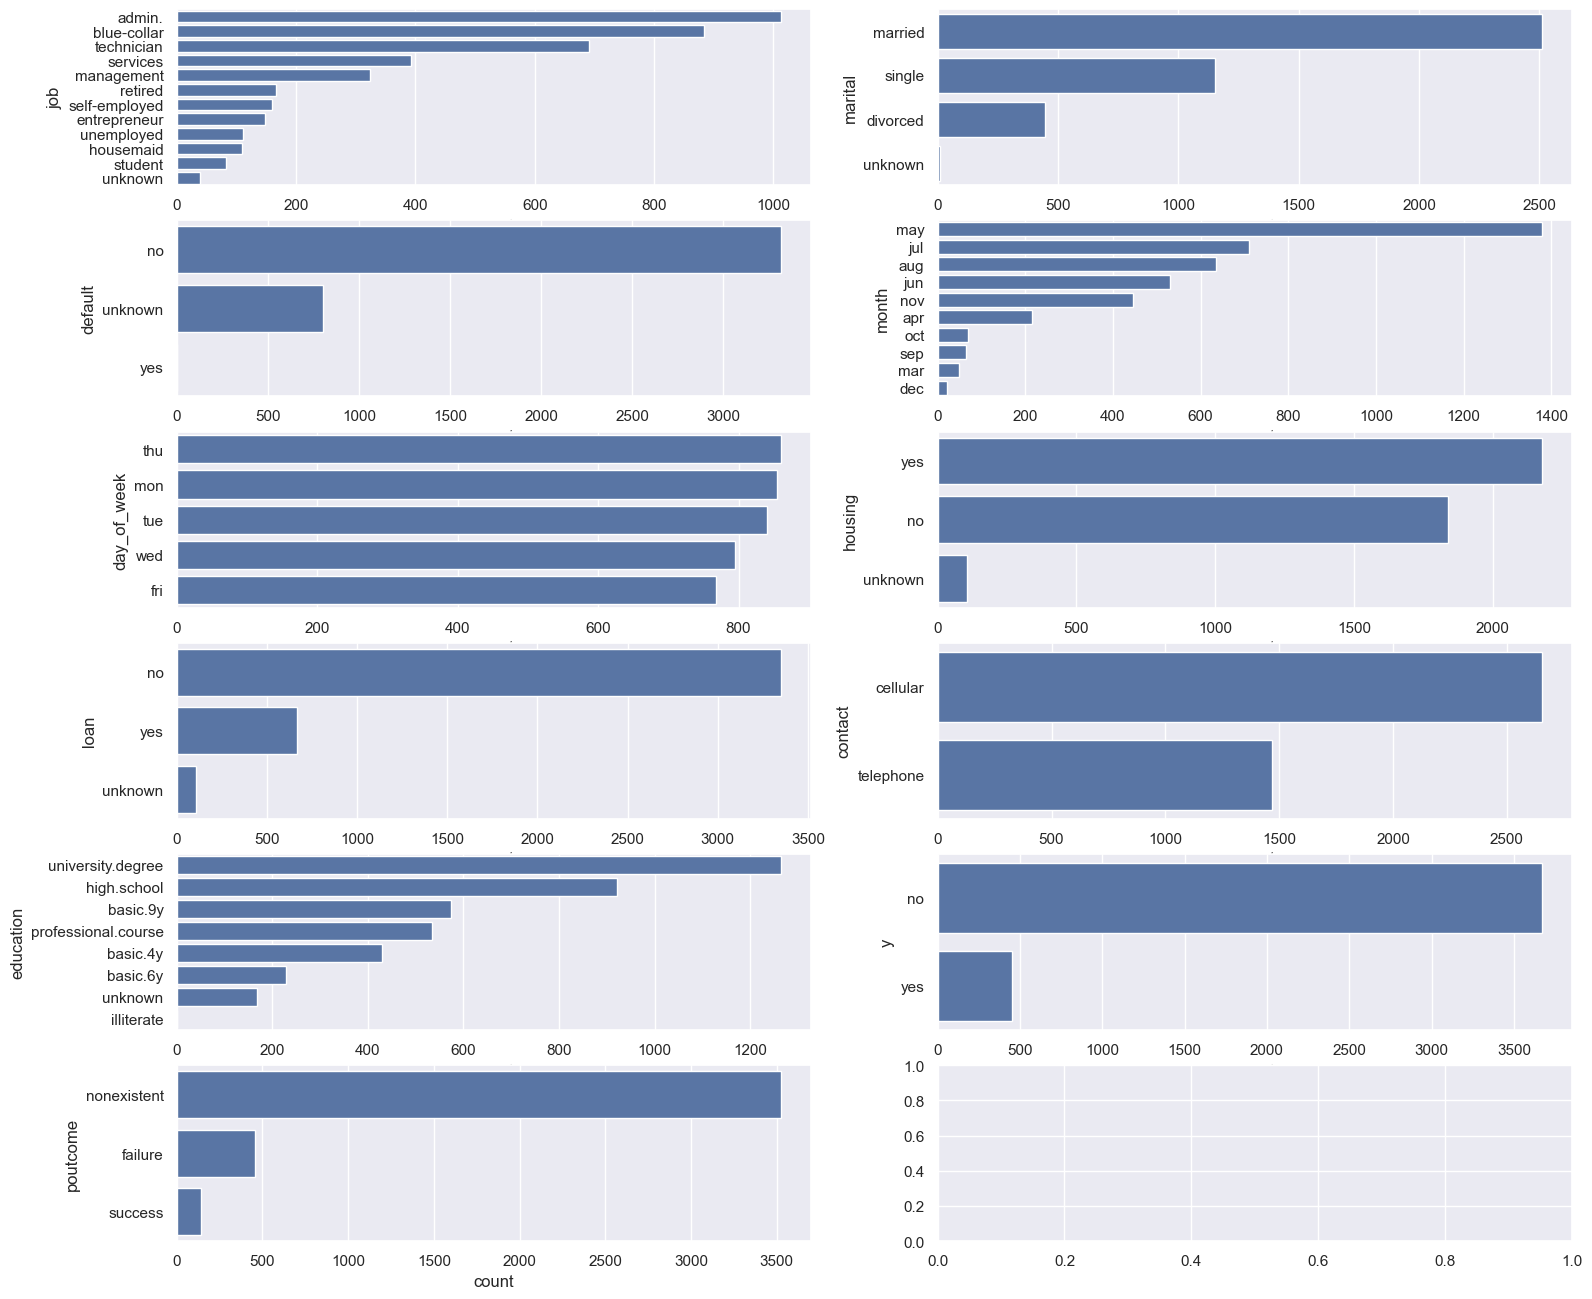

In [7]:
ci = 0
fig, axes = plt.subplots(6, 2, figsize = (18, 16))
for i in range(0, 6):
    for j in range(0, 2):
        if ci < len(cat_cols):
            xlabels = list(df[cat_cols[ci]].unique())
            x = sns.countplot(ax = axes[i][j], data = df, y = cat_cols[ci], order = df[cat_cols[ci]].value_counts().index)
            # x.set_xticklabels(labels = xlabels, rotation = 90)
            # axes[i][j].set_title(f"{cat_cols[ci]}")
            ci += 1
        else:
            pass
# fig.suptitle("categorical columns")
plt.show()

### Numerical Fields

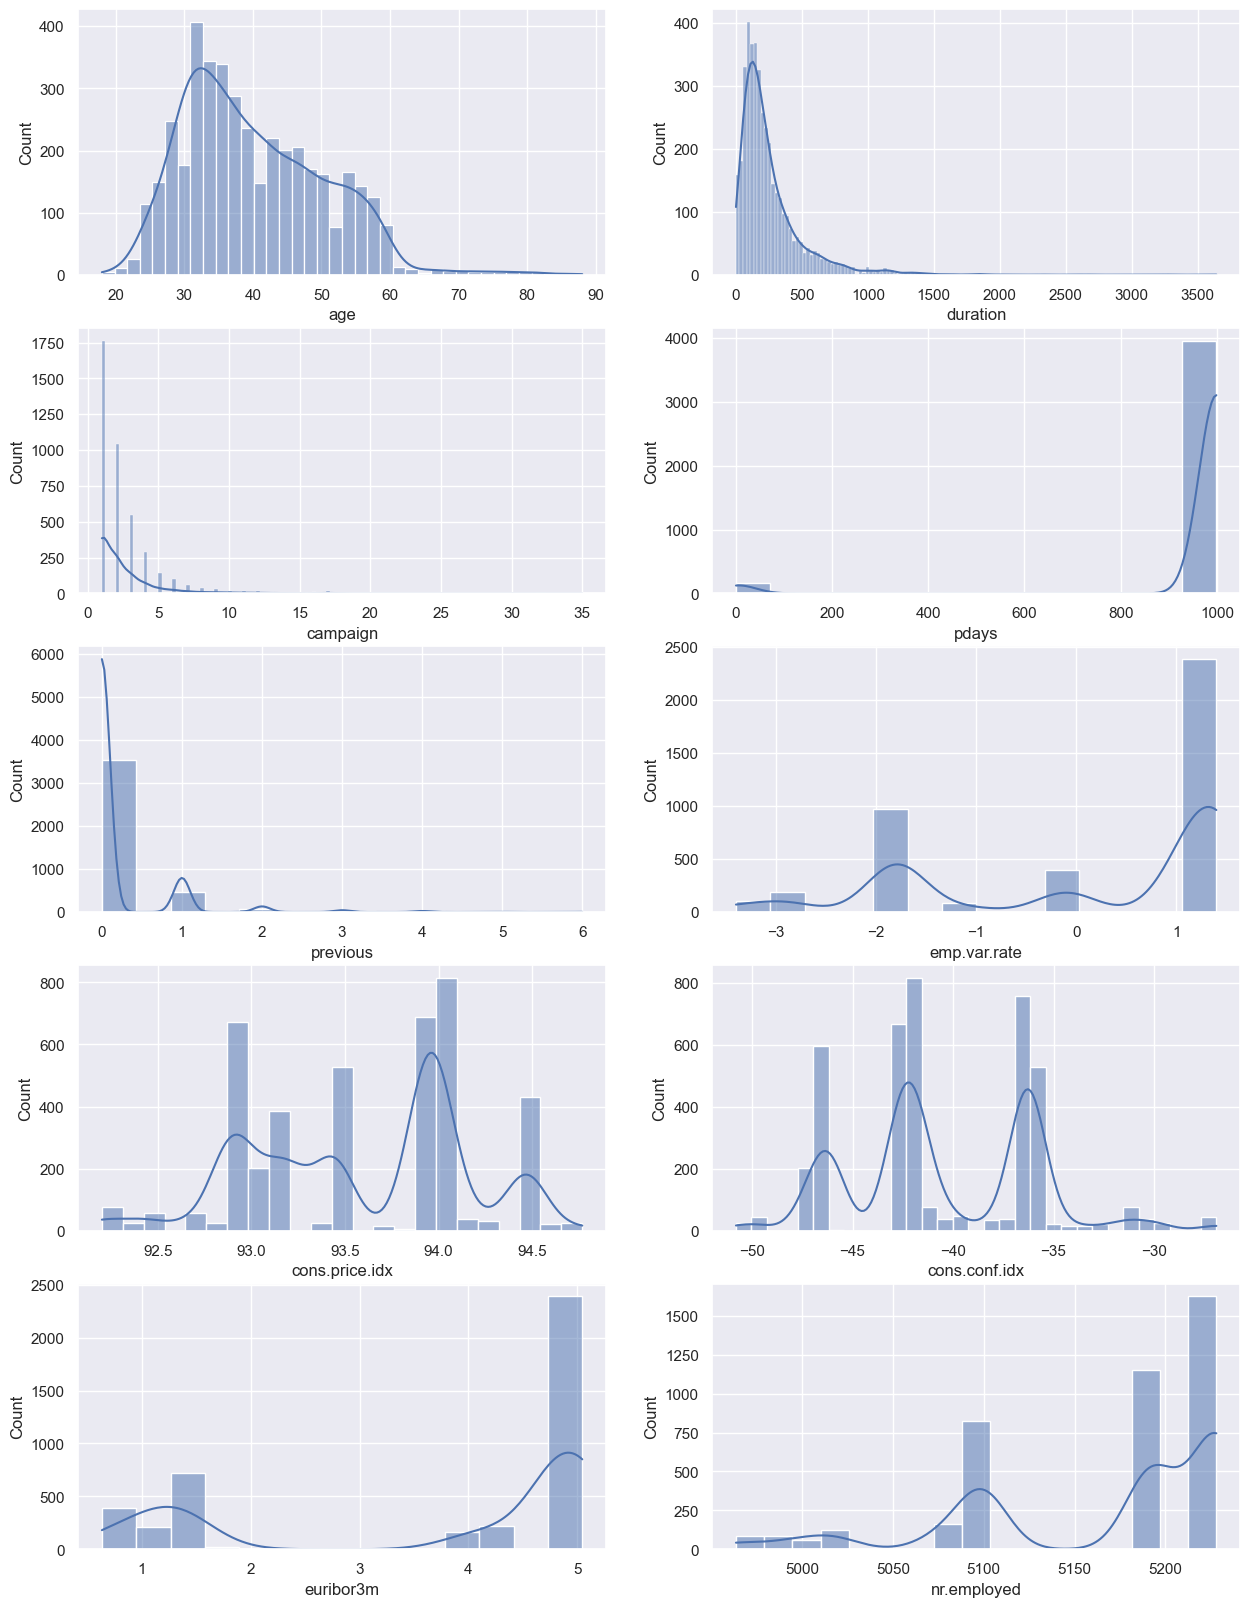

In [8]:
ci = 0
fig, axes = plt.subplots(5, 2, figsize = (15, 20))
for i in range(0, 5):
    for j in range(0, 2):
        if ci < len(num_cols):
            sns.histplot(ax = axes[i][j], data = df, x = num_cols[ci], kde = True)
            # x.set_xticklabels(labels = xlabels, rotation = 90)
            # axes[i][j].set_title(f"{num_cols[ci]}")
            ci += 1
        else:
            pass
# fig.suptitle("categorical columns")
plt.show()

## Correlation Matrix (Bivariate Analysis)

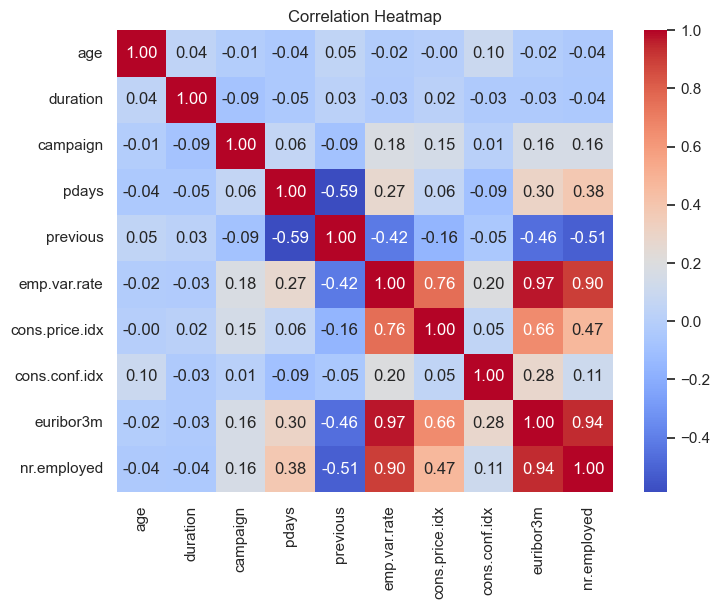

In [9]:
plt.figure(figsize=(8, 6))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

# Data Preprocessing

## Handling Class Imbalance
As observed in the EDA section, target value 0 (no) is roughly 8 times the target value 1 (yes). \
This creates class imbalance during model training, resulting in a biased model and inaccurate classifications. \
The class imbalance is handled by under-sampling the dominant class (no/0)

In [10]:
resample_df = pd.concat([df[df["y"] == "no"].sample(1000, random_state = 101), df[df["y"] == "yes"]])
resample_df.shape

(1451, 21)

In [11]:
X = resample_df.drop("y", axis=1)
y = resample_df["y"]

In [12]:
pd.Series(y).value_counts()

y
no     1000
yes     451
Name: count, dtype: int64

## Preprocessing the Feature Space (X)

In [13]:
# education is an ordinal categorical field hence should be processed (encoded) separately

num_cols = list(X.describe().columns)
cat_cols = list(set(X.columns) - set(num_cols))
ordinal_cols = ['education']
cat_cols = list(set(cat_cols) - set(ordinal_cols))

In [14]:
# Defining the order of importance of the level of education (in ascending order)

ed_cat = ['unknown', 'illiterate', 'basic.4y', 'basic.6y', 'basic.9y', 'high.school', 'professional.course', 'university.degree']

In [15]:
# "One Hot Encoder" is used for the categorical fields to transform them into binary features. The first category of each field is dropped to avoid collinearity
# "Ordinal Encoder" is used for the education field to preserve the importance of the level of education (defined above)
# "Standard Scaler" is used for scaling the numerical columns to a comparable scale
# All three are packaged together in a single transformer using the ColumnTransformer function

transformer = ColumnTransformer(transformers=[('one_hot_encoder', OneHotEncoder(drop = "first", sparse_output = False), cat_cols)
                                              , ('scaler', StandardScaler(), num_cols)
                                              , ('ordinal_encoder', OrdinalEncoder(categories = [ed_cat]), ordinal_cols)],
                                remainder='passthrough')
transformer.fit(df.drop("y", axis=1))

ColumnTransformer(remainder='passthrough',
                  transformers=[('one_hot_encoder',
                                 OneHotEncoder(drop='first',
                                               sparse_output=False),
                                 ['job', 'marital', 'default', 'month',
                                  'day_of_week', 'housing', 'loan', 'contact',
                                  'poutcome']),
                                ('scaler', StandardScaler(),
                                 ['age', 'duration', 'campaign', 'pdays',
                                  'previous', 'emp.var.rate', 'cons.price.idx',
                                  'cons.conf.idx', 'euribor3m',
                                  'nr.employed']),
                                ('ordinal_encoder',
                                 OrdinalEncoder(categories=[['unknown',
                                                             'illiterate',
                                                             'basic.4y',
                                                             'basic.6y',
                                                             'basic.9y',
                                                             'high.school',
                                                             'professional.course',
                                                             'university.degree']]),
                                 ['education'])])

In [16]:
# Saving the transformer in a pickle file for later use

pickle.dump(transformer, open("preprocess_tranformer.pkl", "wb"))

## Preprocessing the Target (y)

In [17]:
# Defining a binary encoder for the target variable y

le = LabelEncoder()
le.fit(df["y"])

LabelEncoder()

In [18]:
pd.Series(y).value_counts()

y
no     1000
yes     451
Name: count, dtype: int64

In [19]:
# Transforming the target variable into a binary field

y = le.transform(y)
pd.Series(y).value_counts()

0    1000
1     451
Name: count, dtype: int64

## Train Test Split

In [20]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size = 0.15, random_state = 101, stratify = y)

In [21]:
# Transform the feature space of the training data (x_train) using the above defined transformer

x_train = transformer.transform(x_train)
x_train.shape

(1233, 47)

In [22]:
# Saving the test data for testing the deployed model API

df_test = x_test.copy()
df_test["y"] = y_test
df_test.to_csv("test_data.csv", index = False)

# Model Selection and Evaluation

## Defualt Model

In [23]:
lr = LogisticRegression()
lr.fit(x_train, y_train)

LogisticRegression()

In [24]:
# Evaluating the default Logistic Regression Model
# Classification is based on the default probability threshold of 0.5

x_test = transformer.transform(x_test)
y_test_pred = lr.predict(x_test)

print(f"ROC AUC: {roc_auc_score(y_test, lr.predict_proba(x_test)[:, 1])}")
print(classification_report(y_test, y_test_pred))

ROC AUC: 0.956078431372549
              precision    recall  f1-score   support

           0       0.89      0.95      0.92       150
           1       0.88      0.75      0.81        68

    accuracy                           0.89       218
   macro avg       0.89      0.85      0.87       218
weighted avg       0.89      0.89      0.89       218



## Hyperparameter Tuning

In [25]:
# Define the base model and the hyper-parameters to be tested

logModel = LogisticRegression()

parameters = {    
        'penalty' : ['l1', 'l2', 'elasticnet', 'none'],
        'fit_intercept': [True, False],
        'solver' : ['lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'],
        'max_iter' : [100, 1000, 10000, 100000]
}

In [26]:
# running the hyperparameter tuning algorithm with 5 fold cross validation and F1 score as the scoring mechanism

clf = GridSearchCV(logModel, param_grid = parameters, cv = 5, scoring = 'f1', verbose=True, n_jobs=-1)
clf.fit(x_train, y_train)

Fitting 5 folds for each of 192 candidates, totalling 960 fits


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The ma

GridSearchCV(cv=5, estimator=LogisticRegression(), n_jobs=-1,
             param_grid={'fit_intercept': [True, False],
                         'max_iter': [100, 1000, 10000, 100000],
                         'penalty': ['l1', 'l2', 'elasticnet', 'none'],
                         'solver': ['lbfgs', 'liblinear', 'newton-cg',
                                    'newton-cholesky', 'sag', 'saga']},
             scoring='f1', verbose=True)

In [27]:
best_lr = clf.best_estimator_
best_lr

LogisticRegression(max_iter=1000, solver='sag')

In [28]:
y_test_pred = best_lr.predict(x_test)

print(f"ROC AUC: {roc_auc_score(y_test, best_lr.predict_proba(x_test)[:, 1])}")
print(classification_report(y_test, y_test_pred))

ROC AUC: 0.9559803921568626
              precision    recall  f1-score   support

           0       0.89      0.95      0.92       150
           1       0.88      0.75      0.81        68

    accuracy                           0.89       218
   macro avg       0.89      0.85      0.87       218
weighted avg       0.89      0.89      0.89       218



max f1 score: 0.8444444444444444
ideal probability threshold: 0.3


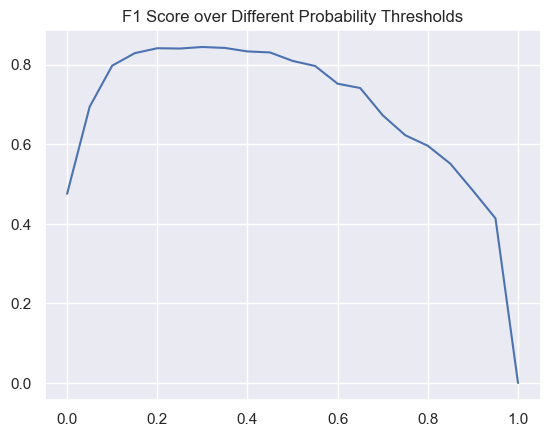

In [29]:
# Finding the probability threshold that optimises the F1 score of the classifier

probs = [x/100 for x in range(0, 101, 5)]
f1_scores = list()

for pt in probs:
    y_hat = [1 if p >= pt else 0 for p in list(best_lr.predict_proba(x_test)[:, -1])]
    f1_scores.append(f1_score(y_test, y_hat))

prob_score_dict = {k:v for k, v in zip(probs, f1_scores)}
print(f"max f1 score: {max(f1_scores)}")
print(f"ideal probability threshold: {max(prob_score_dict, key = prob_score_dict.get)}")

sns.lineplot(x = probs, y = f1_scores)
plt.title("F1 Score over Different Probability Thresholds")
plt.show()

### Final Model Evaluation
The final model after hyperparameter tuning and adjusting the probability threshold gives a F1 Score of 0.84 for the target class (yes/1) \
and ROC-AUC score of 0.956

In [30]:
# Evaluating the model with the custom probability threshold recommended in the above graph

y_pred_proba = best_lr.predict_proba(x_test)[:, -1]
y_pred = [1 if yp >= 0.3 else 0 for yp in y_pred_proba]

print(f"ROC AUC: {roc_auc_score(y_test, best_lr.predict_proba(x_test)[:, 1])}")
print(classification_report(y_test, y_pred))

ROC AUC: 0.9559803921568626
              precision    recall  f1-score   support

           0       0.93      0.93      0.93       150
           1       0.85      0.84      0.84        68

    accuracy                           0.90       218
   macro avg       0.89      0.89      0.89       218
weighted avg       0.90      0.90      0.90       218



In [31]:
# Saving the logistic regression model in a pickle file for later use

pickle.dump(best_lr, open("lr_model.pkl", "wb"))

# API Testing

## Local Deployment

Fast API cli command: "fastapi dev app.py"

In [57]:
url_root = "http://127.0.0.1:8000"

In [58]:
%%time

response = requests.get(url_root)
print(response)
json.loads(response.text)

<Response [200]>
CPU times: user 3.15 ms, sys: 5.88 ms, total: 9.03 ms
Wall time: 16.9 ms


{'Project Name': 'Bank Marketing Campaign Prediction',
 'Description': 'Predict whether a customer will subscribe to a term deposit based on bank marketing data.',
 'API Health': 'Ok'}

In [59]:
test_df = pd.read_csv("test_data.csv")

x_test = test_df.drop("y", axis=1)
y_test = test_df["y"]

In [60]:
url_pred = "http://127.0.0.1:8000/predict"

In [61]:
test_features = x_test

params = {"data": json.dumps(test_features.to_dict(orient='list'))}

In [62]:
%%time

response = requests.get(url_pred, params = params)

print(response)
json.loads(response.text)

<Response [200]>
CPU times: user 37.3 ms, sys: 5.96 ms, total: 43.3 ms
Wall time: 90.6 ms


{'predictions': [0,
  0,
  1,
  0,
  0,
  1,
  1,
  0,
  0,
  0,
  0,
  1,
  1,
  1,
  0,
  0,
  1,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  1,
  0,
  0,
  0,
  0,
  1,
  0,
  1,
  0,
  0,
  0,
  1,
  1,
  0,
  0,
  1,
  0,
  1,
  1,
  0,
  1,
  1,
  1,
  1,
  1,
  0,
  0,
  0,
  1,
  0,
  0,
  0,
  1,
  1,
  0,
  1,
  0,
  0,
  0,
  1,
  0,
  0,
  1,
  0,
  1,
  0,
  0,
  0,
  0,
  0,
  0,
  1,
  0,
  0,
  0,
  1,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  1,
  1,
  1,
  1,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  1,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  1,
  1,
  0,
  1,
  1,
  0,
  0,
  0,
  0,
  0,
  1,
  1,
  0,
  1,
  0,
  1,
  1,
  0,
  0,
  1,
  0,
  0,
  0,
  1,
  0,
  0,
  0,
  1,
  0,
  0,
  1,
  1,
  0,
  0,
  0,
  0,
  0,
  0,
  1,
  0,
  0,
  1,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  1,
  0,
  1,
  0,
  0,
  0,
  0,
  0,
  0,
  1,
  0,
  0,
  1,
  1,
  1,
  1,
  1,
  0,
  0,
  0,
  0,
  1,
  1,
  0,
  0,
  0,
  0,
  0,
  0,


In [63]:
y_test_pred = json.loads(response.text)["predictions"]

print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

           0       0.93      0.93      0.93       150
           1       0.85      0.84      0.84        68

    accuracy                           0.90       218
   macro avg       0.89      0.89      0.89       218
weighted avg       0.90      0.90      0.90       218



## Docker Deployment on Local

docker build CLI command: docker build -t bank-additional-image . \
docker run CLI command: docker run -d --name bank-additional-container -p 80:80 bank-additional-image

In [25]:
url_root = "http://0.0.0.0:80"

In [26]:
%%time

response = requests.get(url_root)
print(response)
json.loads(response.text)

<Response [200]>
CPU times: user 3.49 ms, sys: 6.07 ms, total: 9.56 ms
Wall time: 40.2 ms


{'Project Name': 'Bank Marketing Campaign Prediction',
 'Description': 'Predict whether a customer will subscribe to a term deposit based on bank marketing data.',
 'API Health': 'Ok'}

In [27]:
test_df = pd.read_csv("test_data.csv")

x_test = test_df.drop("y", axis=1)
y_test = test_df["y"]

In [28]:
url_pred = "http://0.0.0.0:80/predict"

In [29]:
test_features = x_test

params = {"data": json.dumps(test_features.to_dict(orient='list'))}

In [30]:
%%time

response = requests.get(url_pred, params = params)

print(response)
json.loads(response.text)

<Response [200]>
CPU times: user 3.84 ms, sys: 5.33 ms, total: 9.17 ms
Wall time: 42.2 ms


{'predictions': [0, 1]}

In [ ]:
y_test_pred = json.loads(response.text)["predictions"]

print(classification_report(y_test, y_test_pred))

## AWS Deployment

In [46]:
url_root = "http://16.171.208.7:80" 

In [47]:
%%time

response = requests.get(url_root)
print(response)
json.loads(response.text)

<Response [200]>
CPU times: user 4.15 ms, sys: 10.1 ms, total: 14.2 ms
Wall time: 382 ms


{'Project Name': 'Bank Marketing Campaign Prediction',
 'Description': 'Predict whether a customer will subscribe to a term deposit based on bank marketing data.',
 'API Health': 'Ok'}

In [48]:
test_df = pd.read_csv("test_data.csv")

x_test = test_df.drop("y", axis=1)
y_test = test_df["y"]

In [49]:
url_pred = "http://16.171.208.7:80/predict"

In [50]:
test_features = x_test

params = {"data": json.dumps(test_features.to_dict(orient='list'))}

In [51]:
%%time

response = requests.get(url_pred, params = params)

print(response)
json.loads(response.text)

<Response [200]>
CPU times: user 7.04 ms, sys: 4.88 ms, total: 11.9 ms
Wall time: 387 ms


{'predictions': [0, 1]}

In [56]:
y_test_pred = json.loads(response.text)["predictions"]

print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         1

    accuracy                           1.00         2
   macro avg       1.00      1.00      1.00         2
weighted avg       1.00      1.00      1.00         2

